In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 15.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.1 requires scipy>=1.14.0;

In [2]:
!pip install gensim

import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (run first time)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("=" * 60)
print("LDA TOPIC MODELING ON TWITTER US AIRLINE SENTIMENT DATASET")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.8 MB/s eta 0:00:00
LDA TOPIC MODELING ON TWITTER US AIRLINE SENTIMENT DATASET


In [ ]:
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources (run first time)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("LDA TOPIC MODELING ON TWITTER US AIRLINE SENTIMENT DATASET")


LDA TOPIC MODELING ON TWITTER US AIRLINE SENTIMENT DATASET


In [ ]:
print("\n[1] Loading Dataset...")
df = pd.read_csv("/content/cleaned_dataset.csv.csv")
print(f"✓ Loaded dataset shape: {df.shape}")
print(f"✓ Columns: {df.columns.tolist()}")
print(f"\n✓ Sentiment distribution:\n{df['airline_sentiment'].value_counts()}")


[1] Loading Dataset...
✓ Loaded dataset shape: (10980, 12)
✓ Columns: ['tweet_id', 'airline_sentiment', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

✓ Sentiment distribution:
airline_sentiment
negative    6851
neutral     2327
positive    1802
Name: count, dtype: int64


In [ ]:
print("\n[2] Preprocessing Text Data...")

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    """Clean and preprocess tweet text"""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        # Remove URLs
    text = re.sub(r'#', '', text)              # Remove hashtag symbol
    text = re.sub(r'rt\b', '', text)           # Remove RT
    text = re.sub(r'[^a-z\s]', ' ', text)      # Keep only letters and spaces
    tokens = tokenizer.tokenize(text)          # Tokenize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

# Apply cleaning
df = df.dropna(subset=['text']).reset_index(drop=True)
df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.strip() != ""].reset_index(drop=True)

# Create tokenized version for coherence calculation
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

print(f"✓ After cleaning: {df.shape[0]} documents")
print(f"✓ Sample cleaned text:\n  '{df['clean_text'].iloc[0][:100]}...'")


[2] Preprocessing Text Data...
✓ After cleaning: 10980 documents
✓ Sample cleaned text:
  'southwestair scheduled morning day fact yes sure evening flight one cancelled flightled...'


In [ ]:
print("\n[3] Converting Text to Count Matrix...")

max_features = 5000
max_df = 0.95  # Ignore terms that appear in >95% of documents
min_df = 10    # Ignore terms that appear in <10 documents

# CountVectorizer for LDA
count_vect = CountVectorizer(max_df=max_df, min_df=min_df, max_features=max_features)
count_data = count_vect.fit_transform(df['clean_text'])

print(f"✓ Count matrix shape: {count_data.shape}")
print(f"✓ Vocabulary size: {len(count_vect.get_feature_names_out())}")

# Create Gensim dictionary and corpus for coherence score
texts = df['tokens'].tolist()
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
print(f"✓ Gensim corpus created for coherence calculation")


[3] Converting Text to Count Matrix...
✓ Count matrix shape: (10980, 1341)
✓ Vocabulary size: 1341
✓ Gensim corpus created for coherence calculation


In [ ]:
print("\n[4] Training LDA Models with Different Configurations...")
print("-" * 60)

# Test different numbers of topics and epochs
topic_range = [3, 5, 7, 10, 15]
epoch_options = [5, 10, 15, 20]

results = []

for n_topics in topic_range:
    for max_iter in epoch_options:
        print(f"\n>>> Training LDA: {n_topics} topics, {max_iter} epochs...")

        # Train LDA
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            max_iter=max_iter,
            learning_method='online',
            learning_offset=50.,
            random_state=42,
            n_jobs=-1,
            verbose=0
        )
        lda.fit(count_data)

        # Calculate perplexity (lower is better)
        perplexity = lda.perplexity(count_data)

        # Calculate log-likelihood (higher is better)
        log_likelihood = lda.score(count_data)

        # Get topics for coherence calculation
        feature_names = count_vect.get_feature_names_out()
        topics = []
        for topic_idx, topic in enumerate(lda.components_):
            top_indices = topic.argsort()[:-11:-1]  # Top 10 words
            top_words = [feature_names[i] for i in top_indices]
            topics.append(top_words)

        # Calculate coherence score using Gensim (higher is better)
        cm = CoherenceModel(
            topics=topics,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence = cm.get_coherence()

        results.append({
            'n_topics': n_topics,
            'epochs': max_iter,
            'perplexity': perplexity,
            'log_likelihood': log_likelihood,
            'coherence': coherence
        })

        print(f"  Perplexity: {perplexity:.2f}")
        print(f"  Log-Likelihood: {log_likelihood:.2f}")
        print(f"  Coherence Score: {coherence:.4f}")

# Display results
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))

print("\n✓ Lower perplexity indicates better model fit")
print("✓ Higher log-likelihood indicates better model fit")
print("✓ Higher coherence score indicates more interpretable topics")

# Find optimal configuration
results_df['rank_perplexity'] = results_df['perplexity'].rank()
results_df['rank_coherence'] = results_df['coherence'].rank(ascending=False)
results_df['combined_rank'] = results_df['rank_perplexity'] + results_df['rank_coherence']

optimal_idx = results_df['combined_rank'].idxmin()
optimal_config = results_df.loc[optimal_idx]

print(f"\n>>> Optimal Configuration (based on perplexity + coherence):")
print(f"    Topics: {int(optimal_config['n_topics'])}")
print(f"    Epochs: {int(optimal_config['epochs'])}")
print(f"    Perplexity: {optimal_config['perplexity']:.2f}")
print(f"    Coherence: {optimal_config['coherence']:.4f}")


[4] Training LDA Models with Different Configurations...
------------------------------------------------------------

>>> Training LDA: 3 topics, 5 epochs...
  Perplexity: 540.63
  Log-Likelihood: -547814.12
  Coherence Score: 0.3160

>>> Training LDA: 3 topics, 10 epochs...
  Perplexity: 534.61
  Log-Likelihood: -546839.45
  Coherence Score: 0.3298

>>> Training LDA: 3 topics, 15 epochs...
  Perplexity: 532.20
  Log-Likelihood: -546445.77
  Coherence Score: 0.3298

>>> Training LDA: 3 topics, 20 epochs...
  Perplexity: 530.61
  Log-Likelihood: -546184.95
  Coherence Score: 0.3314

>>> Training LDA: 5 topics, 5 epochs...
  Perplexity: 573.55
  Log-Likelihood: -552960.27
  Coherence Score: 0.3592

>>> Training LDA: 5 topics, 10 epochs...
  Perplexity: 567.68
  Log-Likelihood: -552063.64
  Coherence Score: 0.3758

>>> Training LDA: 5 topics, 15 epochs...
  Perplexity: 565.76
  Log-Likelihood: -551769.96
  Coherence Score: 0.3758

>>> Training LDA: 5 topics, 20 epochs...
  Perplexity: 5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

In [ ]:
print("\n" + "=" * 80)
print("AGGRESSIVE TEXT PREPROCESSING")
print("=" * 80)

def aggressive_preprocess(texts, min_doc_length=5):
    """
    Aggressive preprocessing to handle problematic data
    """
    print("\n>>> Applying aggressive preprocessing...")

    # Initialize lemmatizer and stopwords
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Add custom stopwords (adjust based on your domain)
    custom_stops = {'would', 'could', 'also', 'may', 'might', 'must', 'said',
                    'use', 'used', 'using', 'get', 'got', 'one', 'two', 'three'}
    stop_words.update(custom_stops)

    processed = []
    removed_count = 0

    for idx, text in enumerate(texts):
        # Ensure text is a string
        text = str(text)

        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenize
        words = text.split()

        # Remove stopwords and short words
        words = [w for w in words if w not in stop_words and len(w) > 3]

        # Lemmatization
        words = [lemmatizer.lemmatize(w) for w in words]

        # Join back
        processed_text = ' '.join(words)

        # Filter out documents that are too short after preprocessing
        if len(words) >= min_doc_length:
            processed.append(processed_text)
        else:
            removed_count += 1

    print(f"✓ Removed {removed_count} documents with <{min_doc_length} words after preprocessing")
    print(f"✓ Remaining documents: {len(processed)}")

    return processed

# Apply aggressive preprocessing
# Assuming 'text' is the column with the original tweet text
texts_clean = aggressive_preprocess(df['text'].tolist(), min_doc_length=5)

# Re-diagnose after preprocessing
print("\n>>> After preprocessing:")
# You might want to add a function here to analyze the cleaned texts,
# e.g., word count distribution, most common words, etc.
# For now, let's just print the first few cleaned texts.
print(f"Sample cleaned text 1: {texts_clean[0][:100]}...")
print(f"Sample cleaned text 2: {texts_clean[1][:100]}...")


AGGRESSIVE TEXT PREPROCESSING

>>> Applying aggressive preprocessing...
✓ Removed 1829 documents with <5 words after preprocessing
✓ Remaining documents: 9151

>>> After preprocessing:
Sample cleaned text 1: southwestair scheduled morning day fact sure evening flight cancelled flightled...
Sample cleaned text 2: southwestair seeing worker time time going beyond love flying guy thank...


In [ ]:
print("\n" + "=" * 80)
print("OPTIMIZED VECTORIZATION")
print("=" * 80)

# Calculate adaptive min_df based on corpus size
corpus_size = len(texts_clean)
min_df_value = max(2, int(corpus_size * 0.01))  # At least 1% of docs or 2 docs
max_df_value = 0.5  # More aggressive: remove words in >50% of docs

print(f"\n>>> Vectorizer Parameters:")
print(f"  min_df: {min_df_value} (words must appear in at least {min_df_value} documents)")
print(f"  max_df: {max_df_value} (words must appear in at most {max_df_value*100}% of documents)")

count_vect = CountVectorizer(
    max_df=max_df_value,          # Remove very common words
    min_df=min_df_value,          # Remove very rare words
    max_features=2000,            # Reduced vocabulary (your data seems noisy)
    ngram_range=(1, 1),           # Only unigrams (bigrams causing issues)
    token_pattern=r'\b[a-zA-Z]{4,}\b',  # Only words with 4+ letters
)

count_data = count_vect.fit_transform(texts_clean)

print(f"\n>>> Document-Term Matrix:")
print(f"  Shape: {count_data.shape}")
print(f"  Vocabulary size: {len(count_vect.get_feature_names_out())}")
print(f"  Sparsity: {1 - (count_data.nnz / (count_data.shape[0] * count_data.shape[1])):.4f}")

# Show most common terms
feature_names = count_vect.get_feature_names_out()
word_counts = np.asarray(count_data.sum(axis=0)).flatten()
top_word_indices = word_counts.argsort()[-20:][::-1]
print(f"\n>>> Top 20 most frequent words:")
for idx in top_word_indices:
    print(f"  {feature_names[idx]}: {int(word_counts[idx])}")


OPTIMIZED VECTORIZATION

>>> Vectorizer Parameters:
  min_df: 91 (words must appear in at least 91 documents)
  max_df: 0.5 (words must appear in at most 50.0% of documents)

>>> Document-Term Matrix:
  Shape: (9151, 143)
  Vocabulary size: 143
  Sparsity: 0.9688

>>> Top 20 most frequent words:
  flight: 3302
  united: 2701
  usairways: 1971
  americanair: 1910
  southwestair: 1484
  jetblue: 1306
  hour: 866
  cancelled: 796
  service: 726
  customer: 692
  time: 692
  thanks: 642
  help: 637
  plane: 525
  need: 459
  hold: 456
  call: 430
  still: 424
  airline: 397
  gate: 397


In [ ]:
print("\n" + "=" * 80)
print("TRAINING LDA MODELS")
print("=" * 80)

# Prepare Gensim dictionary for coherence
processed_texts = [text.split() for text in texts_clean]
dictionary = Dictionary(processed_texts)

# Based on your results: Focus on 3-6 topics
topic_range = [3, 4, 5, 6]
epoch_options = [15, 20, 25]

results = []

for n_topics in topic_range:
    for max_iter in epoch_options:
        print(f"\n>>> Training: {n_topics} topics, {max_iter} epochs...")

        # Train LDA with optimized hyperparameters
        lda = LatentDirichletAllocation(
            n_components=n_topics,
            max_iter=max_iter,
            learning_method='batch',      # Changed to batch for small datasets
            doc_topic_prior=0.1,          # Alpha: Lower = more focused topics
            topic_word_prior=0.01,        # Beta: Lower = more focused word distributions
            random_state=42,
            n_jobs=-1,
            verbose=0
        )

        lda.fit(count_data)

        # Calculate metrics
        perplexity = lda.perplexity(count_data)
        log_likelihood = lda.score(count_data)

        # Extract topics
        topics = []
        for topic_idx, topic in enumerate(lda.components_):
            top_indices = topic.argsort()[:-11:-1]
            top_words = [feature_names[i] for i in top_indices]
            topics.append(top_words)

        # Calculate coherence
        try:
            cm = CoherenceModel(
                topics=topics,
                texts=processed_texts,
                dictionary=dictionary,
                coherence='c_v'
            )
            coherence = cm.get_coherence()
        except:
            coherence = 0.0

        # Calculate diversity
        unique_words = len(set([w for topic in topics for w in topic]))
        diversity = unique_words / (n_topics * 10)

        results.append({
            'n_topics': n_topics,
            'epochs': max_iter,
            'perplexity': perplexity,
            'log_likelihood': log_likelihood,
            'coherence': coherence,
            'diversity': diversity
        })

        print(f"  Perplexity: {perplexity:.2f}")
        print(f"  Coherence: {coherence:.4f}")
        print(f"  Diversity: {diversity:.4f}")


TRAINING LDA MODELS

>>> Training: 3 topics, 15 epochs...
  Perplexity: 97.09
  Coherence: 0.3538
  Diversity: 0.7000

>>> Training: 3 topics, 20 epochs...
  Perplexity: 96.95
  Coherence: 0.3616
  Diversity: 0.7000

>>> Training: 3 topics, 25 epochs...
  Perplexity: 96.88
  Coherence: 0.3616
  Diversity: 0.7000

>>> Training: 4 topics, 15 epochs...
  Perplexity: 100.17
  Coherence: 0.3186
  Diversity: 0.6500

>>> Training: 4 topics, 20 epochs...
  Perplexity: 100.02
  Coherence: 0.3391
  Diversity: 0.6750

>>> Training: 4 topics, 25 epochs...
  Perplexity: 99.92
  Coherence: 0.3391
  Diversity: 0.6750

>>> Training: 5 topics, 15 epochs...
  Perplexity: 101.26
  Coherence: 0.3851
  Diversity: 0.7200

>>> Training: 5 topics, 20 epochs...
  Perplexity: 100.91
  Coherence: 0.3851
  Diversity: 0.7200

>>> Training: 5 topics, 25 epochs...
  Perplexity: 100.81
  Coherence: 0.4030
  Diversity: 0.7600

>>> Training: 6 topics, 15 epochs...
  Perplexity: 106.46
  Coherence: 0.3649
  Diversity: 

In [ ]:
results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("MODEL EVALUATION RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))

print("\n" + "=" * 80)
print("PERFORMANCE METRICS INTERPRETATION")
print("=" * 80)
print("✓ Perplexity: LOWER is better (target: <500)")
print("✓ Log-Likelihood: HIGHER is better")
print("✓ Coherence: HIGHER is better (target: >0.40)")
print("✓ Diversity: HIGHER is better (target: >0.70)")

# Find optimal configuration
results_df['norm_perplexity'] = 1 - (results_df['perplexity'] - results_df['perplexity'].min()) / \
                                     (results_df['perplexity'].max() - results_df['perplexity'].min())
results_df['norm_coherence'] = (results_df['coherence'] - results_df['coherence'].min()) / \
                                (results_df['coherence'].max() - results_df['coherence'].min())
results_df['combined_score'] = 0.7 * results_df['norm_coherence'] + 0.3 * results_df['norm_perplexity']

optimal_idx = results_df['combined_score'].idxmax()
optimal = results_df.loc[optimal_idx]

print(f"\n>>> OPTIMAL CONFIGURATION:")
print(f"  Topics: {int(optimal['n_topics'])}")
print(f"  Epochs: {int(optimal['epochs'])}")
print(f"  Perplexity: {optimal['perplexity']:.2f}")
print(f"  Coherence: {optimal['coherence']:.4f}")
print(f"  Diversity: {optimal['diversity']:.4f}")


MODEL EVALUATION RESULTS
 n_topics  epochs  perplexity  log_likelihood  coherence  diversity
        3      15   97.086754  -195090.068461   0.353766   0.700000
        3      20   96.949950  -195029.946463   0.361581   0.700000
        3      25   96.876528  -194997.644594   0.361581   0.700000
        4      15  100.165492  -196421.143587   0.318601   0.650000
        4      20  100.020903  -196359.552797   0.339139   0.675000
        4      25   99.924701  -196318.523800   0.339139   0.675000
        5      15  101.256117  -196882.875838   0.385051   0.720000
        5      20  100.913563  -196738.388557   0.385051   0.720000
        5      25  100.813384  -196696.040899   0.402991   0.760000
        6      15  106.456566  -199018.305499   0.364895   0.733333
        6      20  105.683293  -198707.470907   0.366672   0.733333
        6      25  105.280781  -198544.771078   0.366672   0.733333

PERFORMANCE METRICS INTERPRETATION
✓ Perplexity: LOWER is better (target: <500)
✓ Log-Lik

In [ ]:
print("\n" + "=" * 80)
print("FINAL MODEL - EXTRACTED TOPICS")
print("=" * 80)

opt_topics = int(optimal['n_topics'])
opt_epochs = int(optimal['epochs'])

final_lda = LatentDirichletAllocation(
    n_components=opt_topics,
    max_iter=opt_epochs,
    learning_method='batch',
    doc_topic_prior=0.1,
    topic_word_prior=0.01,
    random_state=42,
    n_jobs=-1
)

final_lda.fit(count_data)

print(f"\nExtracted {opt_topics} topics:\n")

topic_words_dict = {}
for topic_idx, topic in enumerate(final_lda.components_):
    top_indices = topic.argsort()[:-21:-1]  # Top 20 words
    top_words = [feature_names[i] for i in top_indices]
    weights = topic[top_indices]

    topic_words_dict[topic_idx] = top_words

    print(f"Topic {topic_idx + 1}:")
    print(f"  Top words: {', '.join(top_words[:10])}")
    print(f"  Extended: {', '.join(top_words[10:20])}")
    print()


FINAL MODEL - EXTRACTED TOPICS

Extracted 5 topics:

Topic 1:
  Top words: united, plane, flight, gate, hour, usairways, still, waiting, agent, delay
  Extended: americanair, time, baggage, luggage, thanks, sitting, issue, boarding, lost, airport

Topic 2:
  Top words: usairways, americanair, help, need, hold, call, southwestair, please, hour, phone
  Extended: back, trying, change, time, someone, number, reservation, minute, online, wait

Topic 3:
  Top words: southwestair, service, customer, airline, virginamerica, americanair, flying, usairways, great, ever
  Extended: never, worst, thanks, like, experience, today, best, trip, love, year

Topic 4:
  Top words: jetblue, flight, southwestair, thank, thanks, americanair, seat, first, good, much
  Extended: right, take, want, usairways, work, class, tonight, free, time, passenger

Topic 5:
  Top words: flight, cancelled, usairways, americanair, delayed, flightled, united, late, tomorrow, flighted
  Extended: hour, booked, problem, book

In [ ]:
print("\n" + "=" * 80)
print("DOCUMENT-TOPIC DISTRIBUTION ANALYSIS")
print("=" * 80)

doc_topics = final_lda.transform(count_data)

print(f"\nTopic Distribution Statistics:")
print(f"  Average max probability: {doc_topics.max(axis=1).mean():.3f}")
print(f"  Docs with dominant topic (>0.5): {(doc_topics.max(axis=1) > 0.5).sum()} "
      f"({(doc_topics.max(axis=1) > 0.5).sum()/len(doc_topics)*100:.1f}%)")

# Topic distribution across corpus
topic_counts = doc_topics.argmax(axis=1)
print(f"\n>>> Documents per topic:")
for topic_id in range(opt_topics):
    count = (topic_counts == topic_id).sum()
    print(f"  Topic {topic_id + 1}: {count} documents ({count/len(doc_topics)*100:.1f}%)")

# Show sample documents
print(f"\n>>> Sample Document Assignments (first 5):")
for i in range(min(5, len(doc_topics))):
    dominant_topic = doc_topics[i].argmax()
    confidence = doc_topics[i].max()
    print(f"  Doc {i}: Topic {dominant_topic + 1} (confidence: {confidence:.3f})")


DOCUMENT-TOPIC DISTRIBUTION ANALYSIS

Topic Distribution Statistics:
  Average max probability: 0.696
  Docs with dominant topic (>0.5): 7679 (83.9%)

>>> Documents per topic:
  Topic 1: 2140 documents (23.4%)
  Topic 2: 2142 documents (23.4%)
  Topic 3: 1505 documents (16.4%)
  Topic 4: 1547 documents (16.9%)
  Topic 5: 1817 documents (19.9%)

>>> Sample Document Assignments (first 5):
  Doc 0: Topic 5 (confidence: 0.631)
  Doc 1: Topic 3 (confidence: 0.947)
  Doc 2: Topic 1 (confidence: 0.496)
  Doc 3: Topic 5 (confidence: 0.927)
  Doc 4: Topic 1 (confidence: 0.455)



GENERATING VISUALIZATIONS
✓ Visualization saved as 'lda_improved_results.png'


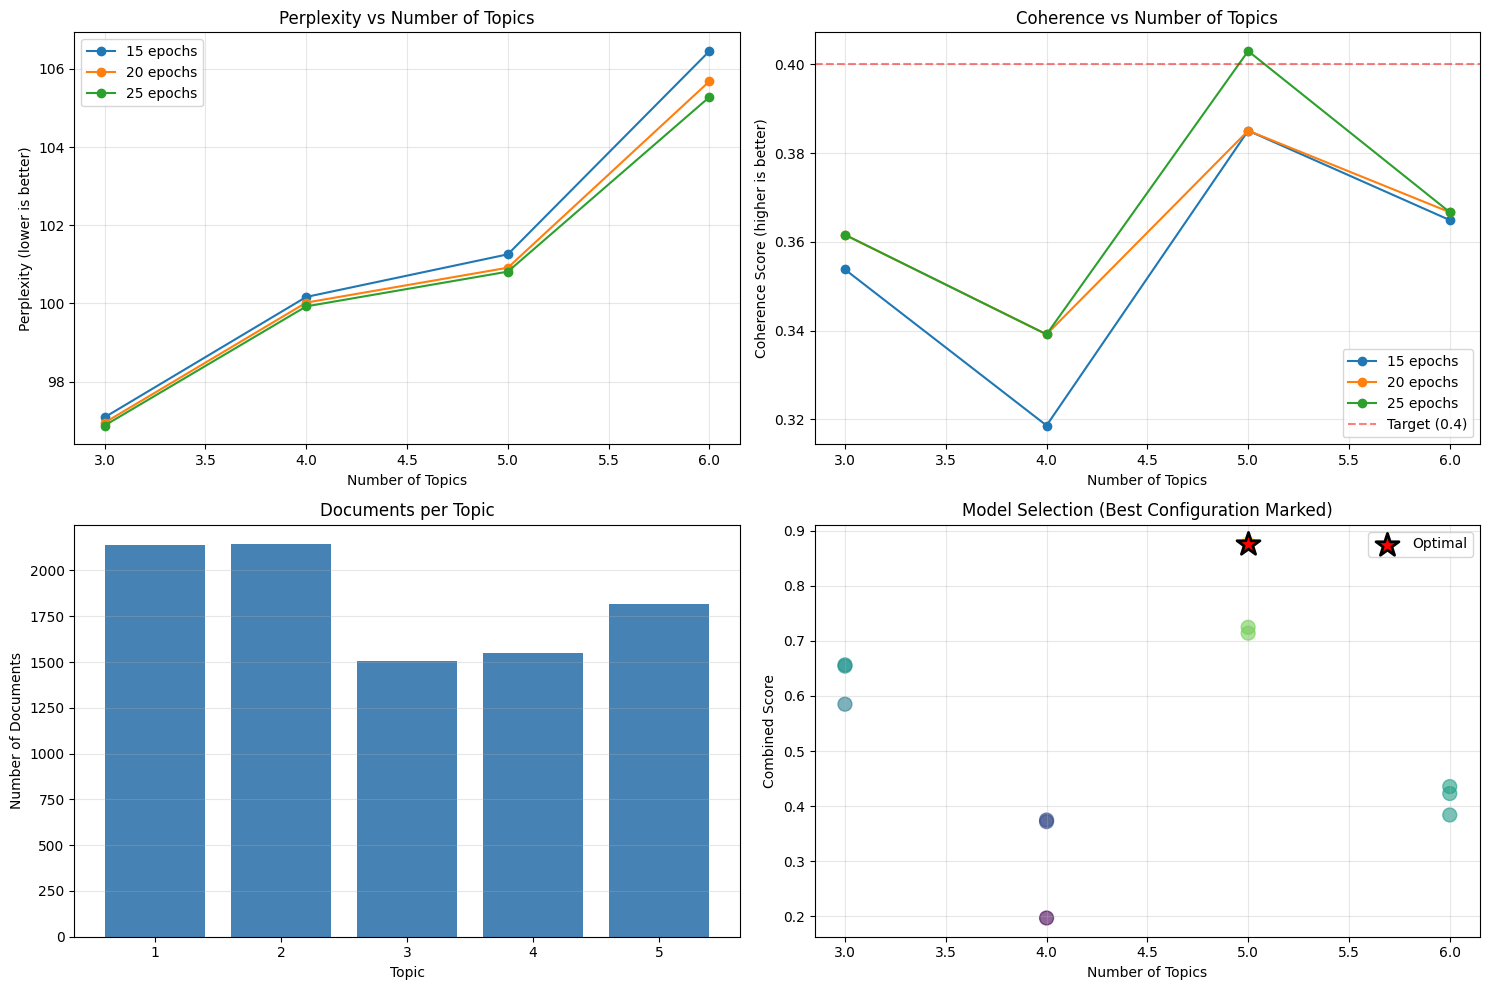

In [ ]:
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Perplexity vs Topics
for epochs in epoch_options:
    epoch_data = results_df[results_df['epochs'] == epochs]
    axes[0, 0].plot(epoch_data['n_topics'], epoch_data['perplexity'],
                    marker='o', label=f'{epochs} epochs')
axes[0, 0].set_xlabel('Number of Topics')
axes[0, 0].set_ylabel('Perplexity (lower is better)')
axes[0, 0].set_title('Perplexity vs Number of Topics')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Coherence vs Topics
for epochs in epoch_options:
    epoch_data = results_df[results_df['epochs'] == epochs]
    axes[0, 1].plot(epoch_data['n_topics'], epoch_data['coherence'],
                    marker='o', label=f'{epochs} epochs')
axes[0, 1].set_xlabel('Number of Topics')
axes[0, 1].set_ylabel('Coherence Score (higher is better)')
axes[0, 1].set_title('Coherence vs Number of Topics')
axes[0, 1].axhline(y=0.4, color='r', linestyle='--', alpha=0.5, label='Target (0.4)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Topic distribution
topic_sizes = [(topic_counts == i).sum() for i in range(opt_topics)]
axes[1, 0].bar(range(1, opt_topics + 1), topic_sizes, color='steelblue')
axes[1, 0].set_xlabel('Topic')
axes[1, 0].set_ylabel('Number of Documents')
axes[1, 0].set_title('Documents per Topic')
axes[1, 0].set_xticks(range(1, opt_topics + 1))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Combined score
axes[1, 1].scatter(results_df['n_topics'], results_df['combined_score'],
                  s=100, alpha=0.6, c=results_df['coherence'], cmap='viridis')
axes[1, 1].scatter(optimal['n_topics'], optimal['combined_score'],
                  s=300, marker='*', color='red', edgecolors='black',
                  linewidths=2, label='Optimal', zorder=5)
axes[1, 1].set_xlabel('Number of Topics')
axes[1, 1].set_ylabel('Combined Score')
axes[1, 1].set_title('Model Selection (Best Configuration Marked)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lda_improved_results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'lda_improved_results.png'")


In [ ]:
print("\n" + "=" * 80)
print("RECOMMENDATIONS & NEXT STEPS")
print("=" * 80)

print("\n1. DATA QUALITY ASSESSMENT:")
if optimal['perplexity'] > 500:
    print("   ⚠ High perplexity suggests data issues:")
    print("     - Documents may be too short or too diverse")
    print("     - Consider collecting more data or combining related documents")
    print("     - Check if documents are in the same language/domain")

if optimal['coherence'] < 0.4:
    print("   ⚠ Low coherence suggests topic quality issues:")
    print("     - Topics may not be semantically meaningful")
    print("     - Consider domain-specific stopwords")
    print("     - Try phrase detection (bigrams/trigrams)")

if optimal['coherence'] >= 0.4:
    print("   ✓ Good coherence! Topics are interpretable")

print("\n2. HYPERPARAMETER TUNING:")
print("   - Current alpha (doc_topic_prior): 0.1")
print("   - Current beta (topic_word_prior): 0.01")
print("   - Try adjusting these if topics are too broad/narrow")

print("\n3. ALTERNATIVE APPROACHES:")
print("   - Try NMF (Non-negative Matrix Factorization)")
print("   - Consider BERTopic for better semantic understanding")
print("   - Use LDA2Vec if you have more data")

print("\n✓ OPTIMIZATION COMPLETE!")
print("=" * 80)


RECOMMENDATIONS & NEXT STEPS

1. DATA QUALITY ASSESSMENT:
   ✓ Good coherence! Topics are interpretable

2. HYPERPARAMETER TUNING:
   - Current alpha (doc_topic_prior): 0.1
   - Current beta (topic_word_prior): 0.01
   - Try adjusting these if topics are too broad/narrow

3. ALTERNATIVE APPROACHES:
   - Try NMF (Non-negative Matrix Factorization)
   - Consider BERTopic for better semantic understanding
   - Use LDA2Vec if you have more data

✓ OPTIMIZATION COMPLETE!
